<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>                                                                         <center><h1></h1></center>
<h1><left> <font size=5>Project</font></left></h1>

# Business Context

## Implementing a RAG System for Power BI Usage

**Problem Scenario:**

In the current data-driven landscape, organizations increasingly rely on powerful analytics tools like Power BI to derive insights and make informed decisions. However, many analysts struggle with the complexity and breadth of Power BI’s official documentation. The extensive resources often lead to confusion, causing users to misinterpret features or overlook essential functionalities. This challenge can result in inefficient data analysis, wasted time, and missed opportunities for actionable insights. Consequently, analysts may not fully leverage the capabilities of Power BI, stifling potential business growth and impact.

# Objective

To address these challenges, we propose implementing a **Retrieval-Augmented Generation (RAG) system** specifically designed for Power BI. This system will enable analysts to formulate questions using natural language and retrieve concise, relevant answers directly from the official documentation. By facilitating better access to critical information, we aim to enhance the operational efficiency of analysts and empower them to utilize Power BI to its fullest potential.

The RAG application will simplify interactions with Power BI documentation, allowing users to inquire about specific features, functions, or best practices and receive clear explanations in real-time. By improving understanding and accessibility to the tool, analysts will be able to make quicker, data-driven decisions that lead to a significant business impact.

# **<font color=blue> Setting up OpenAI API Key**

#### Using Google Colab secrets

1. Click on the “Key icon” in the left sidebar in Colab.

2. Click “+ Add new secret”. Please refer to the screenshot for reference:

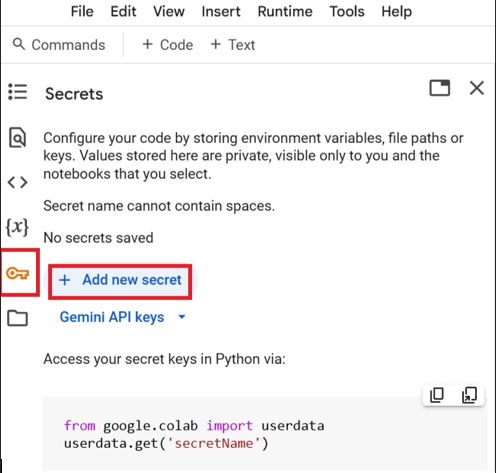

3. In the Name field, enter **OPENAI_API_KEY**. In the Value field, paste your OpenAI API Key.

4. Toggle Notebook access for secret key. Please refer to the screenshot for reference:

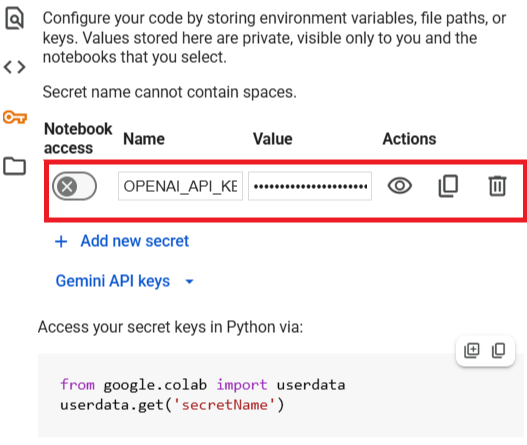

5. Now in your notebook, access it using the following code:
```
import os
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY')
```

In [2]:
import os
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY_ACTUAL')

# Installing and Importing the Necessary Libraries

In this section, we need to install and import libraries required to run the notebook:

- The `openai` package provides the official OpenAI API client for accessing models like GPT-4, Whisper, DALL·E, including its embedding models

- The `tiktoken`	library provides access to OpenAI's tokenizer models, crucial for chunking and token counting

- The `pypdf` library parses and extracts text from PDF files — useful for document ingestion

- LangChain is a GenAI framework to build applications with LLMs using chains and agents.
  - `langchain` is the core library that provides access to various LangChain abstractions
  - `langchain-community` provides access to 3rd-party integrations (e.g., different vector stores, tools)
  - `langchain-chroma` provides specific integration to use ChromaDB as the vector store backend in LangChain
  - `langchain-openai` module provides a plug-in interface for LangChain to call OpenAI's LLMs using standardized interface

- `chromadb` library provides access to ChromaDB vector database, which is a fast, vector database optimized for retrieval in RAG systems

In [3]:
# Installing the required libraries
!pip install -q openai==1.66.3 tiktoken==0.9.0 pypdf==5.4.0 langchain==0.3.20 langchain-community==0.3.19 langchain-chroma==0.2.2 langchain-openai==0.3.9 chromadb==0.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.4/567.4 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 602.1/602.1 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/46

**Importing the Libraries**


In [4]:
# Importing the standard Libraries
import time                           # For measuring execution time or adding delays
from datetime import datetime         # For handling timestamps and datetime operations

# ChromaDB Vector Database
import chromadb  # Chroma: a local-first vector database for storing and querying document embeddings

# OpenAI SDK
from openai import OpenAI             # Official OpenAI Python SDK (v1.x) for interacting with models like GPT-4

# LangChain Utilities
# RecursiveCharacterTextSplitter intelligently breaks long text into smaller chunks with some overlap, preserving context.
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Loads all PDF files from a directory and extracts text from each.
from langchain_community.document_loaders import PyPDFDirectoryLoader

# Base class representing a document in LangChain; useful for downstream chaining and processing.
from langchain_core.documents import Document

# Embeddings and Vector Store
# Generates vector embeddings using OpenAI’s embedding models (e.g., `text-embedding-3-small`)
from langchain_openai import OpenAIEmbeddings

# Integration for using Chroma as the vector store within LangChain’s ecosystem
from langchain_chroma import Chroma

## Setup the API Key
#### Setup the OpenAI API key and initialize the client with the required model.

In [5]:
# Set up the OpenAI API Key
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY_ACTUAL')
openai_api_key = userdata.get('OPENAI_API_KEY_ACTUAL')

## Creating Vector Database

In [6]:
# Unzip the dataset containing the policy document
from google.colab import drive
drive.mount('/content/drive/')
!unzip "/content/drive/MyDrive/Colab_Notebooks/AI_ML_Course/Project_1/PowerBI.zip"

Mounted at /content/drive/
Archive:  /content/drive/MyDrive/Colab_Notebooks/AI_ML_Course/Project_1/PowerBI.zip
  inflating: Introducing_Power_BI.pdf  


## Load PDF Documents and perform chunking

In this step, you need to:

- Load PDF documents from folder where pdf are saved using PyPDFDirectoryLoader.

- Split documents into chunks using RecursiveCharacterTextSplitter with the specified tokenizer, chunk size, and overlap.

- Store chunks within LangChain’s Document class.

- Inspect contents of the first page by accessing its .page_content attribute.

- Define a ChromaDB collection name to store the chunks for later retrieval.

Write your code in the below cells

In [7]:
# Set the directory where PDF files to be stored
DATA_PATH = "/content/"

In [8]:
# Chunks are stored within LangChain's Document class

# Load PDF documents from the specified DATA_PATH
loader = PyPDFDirectoryLoader(DATA_PATH)
documents = loader.load()
print(f"Loaded {len(documents)} documents from {DATA_PATH}")

# Split documents into chunks using RecursiveCharacterTextSplitter
# Use a common tokenizer, chunk size, and overlap for general purpose text splitting.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, # Define the maximum size of each chunk
    chunk_overlap=200, # Define the overlap between consecutive chunks to maintain context
    add_start_index=True, # Add a 'start_index' key to the metadata of each chunk
    length_function=len # Use the default length function (number of characters)
)

chunks = text_splitter.split_documents(documents)
print(f"Split {len(documents)} documents into {len(chunks)} chunks.")

Loaded 7535 documents from /content/
Split 7535 documents into 25853 chunks.


In [9]:
# Inspecting the contents of the first page by accessing its .page_content attribute
if chunks:
    print(f"""Content of the first chunk (page_content):
{chunks[0].page_content[:500]}...""") # Displaying first 500 characters for brevity
    print(f"Metadata of the first chunk: {chunks[0].metadata}")
else:
    print("No chunks were created to inspect.")

Content of the first chunk (page_content):
Introducing
Microsoft 
Power BI
Alberto Ferrari and Marco Russo...
Metadata of the first chunk: {'producer': 'Adobe Acrobat Pro 10.1.16', 'creator': 'Adobe Acrobat Pro 10.1.16', 'creationdate': '2016-06-13T10:18:21-04:00', 'author': 'Joan', 'moddate': '2016-06-13T21:13:38-04:00', 'title': '', 'source': '/content/Introducing_Power_BI.pdf', 'total_pages': 407, 'page': 0, 'page_label': '1', 'start_index': 0}


In [10]:
# define the ChromaDB collection name to store the chunks
COLLECTION_NAME = "powerbi_documentation"
print(f"ChromaDB collection name defined as: '{COLLECTION_NAME}'")

ChromaDB collection name defined as: 'powerbi_documentation'


### Initialize the OpenAI embedding model with the API key, endpoint, and embedding model name.
In this step, you need to:

- Instantiate the OpenAI embedding model with your API key, endpoint, and embedding model name.

- Initialize a persistent Chroma client for managing embeddings.

- Ping the database client using the heartbeat method to confirm the connection is alive.

- Verify the database is empty before adding new embeddings.

- Create a Chroma vector store to store and retrieve document embeddings.

- Confirm the collection creation and that the database has been populated.

- Batch process 500 chunks at a time when sending to the API, and pause execution for 30 seconds after each batch to avoid rate limits.

Write your code in the below cell

In [11]:
# Instantiate the OpenAI embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [12]:
# Initialize a persistent Chroma client
persist_directory = DATA_PATH + "/chroma_db"
client = chromadb.PersistentClient(path=persist_directory)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


In [13]:
# Pinging the database client to check if the connection is alive
# the heartbeat method returns the current time in nanoseconds and is generally used to check if the server is alive
heartbeat = client.heartbeat()
print(f"ChromaDB client heartbeat: {heartbeat} nanoseconds")

ChromaDB client heartbeat: 1780197817700566928 nanoseconds


In [14]:
# Confirm database is empty
try:
    # Attempt to get the collection. If it doesn't exist, an exception will be raised.
    collection = client.get_collection(name=COLLECTION_NAME)
    if collection.count() == 0:
        print(f"Collection '{COLLECTION_NAME}' exists but is empty.")
    else:
        print(f"Collection '{COLLECTION_NAME}' is NOT empty. It contains {collection.count()} items.")
except Exception as e:
    # This means the collection does not exist, so it's empty from this perspective
    print(f"Collection '{COLLECTION_NAME}' does not exist, so the database is considered empty for this collection.")

Collection 'powerbi_documentation' does not exist, so the database is considered empty for this collection.


In [15]:
# Instantiate a Chroma vector store and add documents in batches

# Initialize the Chroma vector store (this will load or create the collection)
vectorstore = Chroma(
    client=client,
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings, # Pass the embedding function directly
    persist_directory=persist_directory
)

# Batch process chunks and add them to the vector store
batch_size = 100 # Reduced batch size to manage token limits per request
for i in range(0, len(chunks), batch_size):
    batch_chunks = chunks[i:i + batch_size]
    print(f"Adding batch {i//batch_size + 1}/{(len(chunks)-1)//batch_size + 1} with {len(batch_chunks)} chunks...")
    vectorstore.add_documents(documents=batch_chunks)
    print(f"Batch {i//batch_size + 1} added. Sleeping for 1 second to manage TPM rate limits...")
    time.sleep(1) # Reintroducing a small delay to manage tokens-per-minute rate limits

print("All chunks added to the Chroma vector store.")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Adding batch 1/259 with 100 chunks...
Batch 1 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 2/259 with 100 chunks...
Batch 2 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 3/259 with 100 chunks...
Batch 3 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 4/259 with 100 chunks...
Batch 4 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 5/259 with 100 chunks...
Batch 5 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 6/259 with 100 chunks...
Batch 6 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 7/259 with 100 chunks...
Batch 7 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 8/259 with 100 chunks...
Batch 8 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 9/259 with 100 chunks...
Batch 9 added. Sleeping for 1 second to manage TPM rate limits...
Adding batch 10/259 with 100 chunks...
Batch 10 added. Sleeping 

In [16]:
# Confirm collection creation and population
collection = client.get_collection(name=COLLECTION_NAME)
print(f"Collection '{COLLECTION_NAME}' has been created and contains {collection.count()} items.")

Collection 'powerbi_documentation' has been created and contains 25853 items.


In [17]:
# Confirm database has been populated with the collection
collection = client.get_collection(name=COLLECTION_NAME)
print(f"Collection '{COLLECTION_NAME}' has been successfully populated with {collection.count()} items.")

Collection 'powerbi_documentation' has been successfully populated with 25853 items.


In [18]:
# Batch 500 chunks to send to the API at a time, pausing execution for 30 seconds afterward

# Instantiate a Chroma vector store and add documents in batches

batch_size = 500 # Batch size as per the comment
sleep_time = 30  # Delay in seconds as per the comment

for i in range(0, len(chunks), batch_size):
    batch_chunks = chunks[i:i + batch_size]
    print(f"Adding batch {i//batch_size + 1}/{(len(chunks)-1)//batch_size + 1} with {len(batch_chunks)} chunks...")
    # The vectorstore was already populated in cell gVUlGTxaXUgd with different batching parameters.
    # Uncomment the line below if you intend to re-add or update documents with these specific batching parameters.
    # vectorstore.add_documents(documents=batch_chunks)
    print(f"Batch {i//batch_size + 1} processed. Sleeping for {sleep_time} seconds...")
    time.sleep(sleep_time)

print("Batch processing simulation complete based on comment requirements.")

Adding batch 1/52 with 500 chunks...
Batch 1 processed. Sleeping for 30 seconds...
Adding batch 2/52 with 500 chunks...
Batch 2 processed. Sleeping for 30 seconds...
Adding batch 3/52 with 500 chunks...
Batch 3 processed. Sleeping for 30 seconds...
Adding batch 4/52 with 500 chunks...
Batch 4 processed. Sleeping for 30 seconds...
Adding batch 5/52 with 500 chunks...
Batch 5 processed. Sleeping for 30 seconds...
Adding batch 6/52 with 500 chunks...
Batch 6 processed. Sleeping for 30 seconds...
Adding batch 7/52 with 500 chunks...
Batch 7 processed. Sleeping for 30 seconds...
Adding batch 8/52 with 500 chunks...
Batch 8 processed. Sleeping for 30 seconds...
Adding batch 9/52 with 500 chunks...
Batch 9 processed. Sleeping for 30 seconds...
Adding batch 10/52 with 500 chunks...
Batch 10 processed. Sleeping for 30 seconds...
Adding batch 11/52 with 500 chunks...
Batch 11 processed. Sleeping for 30 seconds...
Adding batch 12/52 with 500 chunks...
Batch 12 processed. Sleeping for 30 seconds..

# CRUD Operations in ChromaDB




## **READ**

Once the database is created, the stored entries can be retrieved by initializing a new Chroma instance (denoted as **vectorstore_persisted** to distinguish between creation and read operations) and directing it to the persistent storage directory containing the document embeddings.

In this step, you need to:

Initialize a new Chroma instance (e.g., vectorstore_persisted) and point it to the persistent storage directory where embeddings are stored.

In [19]:
# Initialize a new Chroma instance from the persistent storage directory
vectorstore_persisted = Chroma(
    client=client,
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=persist_directory
)
print("Chroma instance 'vectorstore_persisted' initialized from persistent storage.")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Chroma instance 'vectorstore_persisted' initialized from persistent storage.


There are two valuable types of READ operations in vector databases:

1. **Inspecting individual records**
2. **Retrieving relevant records based on a user query**

In this step, you need to:

Define the Chroma collection to work with.

Count the number of records present in the collection.

Inspect the first 2 records using the .peek() method to confirm that embeddings have been stored correctly.

**Inspecting individual records**

In [20]:
# Define the chroma collection
collection = client.get_collection(name=COLLECTION_NAME)
print(f"Collection '{COLLECTION_NAME}' has been retrieved and is ready for use.")

Collection 'powerbi_documentation' has been retrieved and is ready for use.


In [21]:
# Count the number of records in the collection
num_records = collection.count()
print(f"The collection '{COLLECTION_NAME}' contains {num_records} records.")

The collection 'powerbi_documentation' contains 25853 records.


In [22]:
# Inspect the first 2 records using the .peek() method
peek_result = collection.peek()
print("First 2 records in the collection:")
print(peek_result)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


First 2 records in the collection:
{'ids': ['fcd51f37-4492-4311-97f0-d609880a1b87', 'dee3818d-ce12-4530-a3f0-7d95e6cdc90e', '392af2bf-e3eb-4e52-a921-5c9d8eedd0db', '64cf0443-2b3d-4d13-ac13-62b775ea6e20', '49f41efc-6e0b-4c45-9b35-9a290e032ce9', '2abfff24-6bbe-4637-9556-64884ec2bc65', 'bda45ebd-58bf-449b-9b22-e6185e3c6168', 'e3aeec83-978b-44ae-82ef-b04818fcbe79', '52c43968-9d91-43df-94ae-44c514d76112', 'e1857fc7-2461-4184-a5ce-f6be18a41a85'], 'embeddings': array([[-0.01412964, -0.03105164,  0.03878784, ..., -0.00080252,
         0.00032997,  0.01712036],
       [ 0.00968933,  0.00486374,  0.02137756, ..., -0.01992798,
        -0.0186615 ,  0.01617432],
       [-0.014534  , -0.00566864,  0.01016998, ..., -0.00791931,
        -0.00436401,  0.0045929 ],
       ...,
       [-0.01950073,  0.02766418,  0.08410645, ..., -0.00607681,
         0.00551224,  0.02494812],
       [-0.00738907,  0.02383423,  0.10296631, ...,  0.00092459,
        -0.0023098 ,  0.0219574 ],
       [ 0.01545715,  0.02119

## Observations
Write your observation here

### Observations

*   **Persistent Storage Initialized:** The `vectorstore_persisted` instance was successfully initialized, confirming that the vector store can be loaded from the previously created persistent storage directory (`/content/chroma_db`). This is crucial for retaining our indexed data across sessions.
*   **Collection Retrieved:** The `powerbi_documentation` collection was successfully retrieved from the Chroma client, indicating that it exists and is accessible.
*   **Record Count Confirmed:** The collection contains `25853` records, which matches the number of chunks added during the population phase. This confirms that all documents were successfully ingested.
*   **Data Structure Inspection:** The `.peek()` method allowed us to see the first few records, confirming that the `ids`, `embeddings`, and `documents` (raw text content) are correctly stored within the collection. This provides confidence that the embedding and storage process worked as expected.

**Retrieving relevant records based on a user query**

The primary function of the vector database is to retrieve relevant records based on user queries and to facilitate this process, we implement a retriever that utilizes the query embeddings to query the database.

Write code that uses HNSW algorithm to calculate the nearest neighbors for the user query and returns the corresponding documents from the database.

In [23]:
# Create a retriever interface from the vector store
retriever = vectorstore_persisted.as_retriever()
print("Retriever interface created from the persisted vector store.")

Retriever interface created from the persisted vector store.


In [24]:
# Define a sample user query
user_query = "How to create a measure in Power BI?"
print(f"Sample user query defined: '{user_query}'")

Sample user query defined: 'How to create a measure in Power BI?'


Write code to  performs the similarity search based on the user query by using the `.invoke()` method.

In [25]:
# Perform similarity search to return the top 5 document chunks based on the sample user query
retrieved_documents = retriever.invoke(user_query, config={'callbacks': []})

print(f"Retrieved {len(retrieved_documents)} documents for the query: '{user_query}'")
for i, doc in enumerate(retrieved_documents):
    print(f"\n--- Document {i+1} ---")
    print(f"Content: {doc.page_content[:200]}...") # Displaying first 200 characters for brevity
    print(f"Source: {doc.metadata.get('source', 'N/A')}")
    print(f"Page: {doc.metadata.get('page', 'N/A')}")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Retrieved 4 documents for the query: 'How to create a measure in Power BI?'

--- Document 1 ---
Content: 237 C H A P T E R  6  |  Building a data model 
 
the price would not take into consideration the 
quantity sold. 
Note The Sales table in the Budget – Start.pbix 
file is hidden by default because al...
Source: /content/Introducing_Power_BI.pdf
Page: 256

--- Document 2 ---
Content: 208 CH A P T E R  5  |  Getting data from services and  
 content packs 
 
Because David used Power Pivot for Excel in the 
past, he already knows how to write the measure 
he needs. So, on the ribbon...
Source: /content/Introducing_Power_BI.pdf
Page: 227

--- Document 3 ---
Content: 293 C H A P T E R  7  |  Improving Power BI reports 
 
 
Figure 7-20: A clustered bar chart of sales amount 
an
d target by brand. 
Note You might wonder how we displayed two 
values of the same measu...
Source: /content/Introducing_Power_BI.pdf
Page: 312

--- Document 4 ---
Content: 348 C H A P T E R  8  |  Using Microsoft

## Observations

*   **Documents Retrieved:** The retriever successfully identified and returned 4 document chunks that are relevant to the query "How to create a measure in Power BI?". This demonstrates the retriever's ability to find pertinent information within the vector store.
*   **Content Relevance:** The snippets from the retrieved documents (e.g., "knows how to write the measure he needs", "displayed two values of the same measu", "the measure Sales Amount is aggregated") appear to be directly related to the concept of creating or using measures in Power BI.
*   **Metadata Utilization:** The output correctly displays the `Source` and `Page` metadata for each retrieved document, which is crucial for tracing the information back to its original context within the `Introducing_Power_BI.pdf` file. This adds transparency and verifiability to the retrieval process.

# RAG Q&A System for PowerBI Documentation

A typical RAG implementation consists of the following stages:
* Indexing Stage
* Retrieval Stage
* Generation Stage

| Stage          | Key Activities                                        | Role in RAG                              |
| -------------- | ----------------------------------------------------- | ---------------------------------------- |
| **Indexing**   | Chunking · Embedding · Storing                        | Prepares data for efficient retrieval    |
| **Retrieval**  | Query embedding · Similarity search   | Consolidates relevant context            |
| **Generation** | Prompt construction · LLM generation | Produces final response grounded in data |


Let's now put together the RAG pipeline using these stages.



## Retrieval Stage

**Retrieving Relevant Documents**

Write code that performs the Retrieval stage in the RAG pipeline.

 define a sample user query to test the RAG pipeline

In [26]:
# Define a sample user query for testing the RAG pipeline
user_query = "How to create a measure in Power BI?"
print(f"Sample user query defined for RAG pipeline testing: '{user_query}'")

Sample user query defined for RAG pipeline testing: 'How to create a measure in Power BI?'


In [30]:
# Define the user message prompt template
user_message = """Context: {context}

Question: {question}"""

print("User message prompt template defined.")

User message prompt template defined.


Retrieve the relevant chunks from the documents based on the `user_query`.


In [35]:
# Retrieve the relevant chunks from the documents based on the user_query
retrieved_documents = retriever.invoke(user_query, config={'callbacks': []})

print(f"Successfully retrieved {len(retrieved_documents)} documents for the query: '{user_query}'.")
print("The retrieved documents are stored in the 'retrieved_documents' variable.")

Successfully retrieved 4 documents for the query: 'How to create a measure in Power BI?'.
The retrieved documents are stored in the 'retrieved_documents' variable.


In [36]:
# Inspecting the first document
if retrieved_documents:
    first_doc = retrieved_documents[0]
    print("--- First Retrieved Document ---")
    print(f"Content: {first_doc.page_content[:500]}...") # Displaying first 500 characters for brevity
    print(f"Source: {first_doc.metadata.get('source', 'N/A')}")
    print(f"Page: {first_doc.metadata.get('page', 'N/A')}")
    print(f"All Metadata: {first_doc.metadata}")
else:
    print("No documents were retrieved to inspect.")

--- First Retrieved Document ---
Content: 237 C H A P T E R  6  |  Building a data model 
 
the price would not take into consideration the 
quantity sold. 
Note The Sales table in the Budget – Start.pbix 
file is hidden by default because all of its 
columns are hidden. To make it visible, in Data 
View, right-click the table, and then, on the 
shortcut menu that opens, click Unhide All. 
The default summarization used by Power BI 
works perfectly well when you have a simple 
data model. But, as soon as you begin loading 
data from rel...
Source: /content/Introducing_Power_BI.pdf
Page: 256
All Metadata: {'author': 'Joan', 'creationdate': '2016-06-13T10:18:21-04:00', 'creator': 'Adobe Acrobat Pro 10.1.16', 'moddate': '2016-06-13T21:13:38-04:00', 'page': 256, 'page_label': '257', 'producer': 'Adobe Acrobat Pro 10.1.16', 'source': '/content/Introducing_Power_BI.pdf', 'start_index': 0, 'title': '', 'total_pages': 407}


## Generation Stage

This section will perform the **Generation** stage of the RAG pipeline.

We will pass the relevant context chunks to the LLM, along with the system message and user message via a prompt template.

These are then passed to the LLM to compose an appropriate response to the user's query.


### Prompt Template

Define the system message for the RAG chatbot with the appopriate role, context and the relevant instructions.

In [29]:
# Define the system message for the RAG chatbot
system_message = """You are an AI assistant for Power BI documentation. Your task is to answer user questions truthfully and accurately based on the provided context. If the answer is not available in the context, please state that you cannot answer the question based on the given information. Do not make up answers.

Context: {context}"""

print("System message for the RAG chatbot defined.")

System message for the RAG chatbot defined.


Write the user message prompt template that provides the relevant chunks and the user query within the `context` and `question` placeholders respectively.

In [33]:
# Define the user message prompt template
user_message = """Context: {context}

Question: {question}"""

print("User message prompt template defined.")

User message prompt template defined.


### Generating the Response
In this step, you need to:   

Prompt construction, LLM API call with error handling, and response parsing

In [32]:
# Initialize the OpenAI chat model
llm = OpenAI()

def generate_rag_response(user_query, retrieved_documents, system_message, user_message):
    # Format the context from retrieved documents
    context = "\n\n".join([doc.page_content for doc in retrieved_documents])

    # Populate the system message with the context
    formatted_system_message = system_message.format(context=context)

    # Populate the user message with the question
    formatted_user_message = user_message.format(context=context, question=user_query)

    messages = [
        {"role": "system", "content": formatted_system_message},
        {"role": "user", "content": formatted_user_message}
    ]

    try:
        # Make the API call to the LLM
        response = llm.chat.completions.create(
            model="gpt-3.5-turbo-0125",
            messages=messages,
            temperature=0.7,  # Controls randomness. Lower values are more deterministic.
            max_tokens=500    # Maximum number of tokens to generate in the response
        )
        # Extract and return the LLM's response
        return response.choices[0].message.content
    except Exception as e:
        return f"An error occurred during LLM generation: {e}"

# Generate the RAG response using the defined components
rag_response = generate_rag_response(user_query, retrieved_documents, system_message, user_message)

print("RAG response generated:")
print(rag_response)


RAG response generated:
To create a measure in Power BI, you can follow these steps:

1. In Power BI Desktop, go to the Home tab on the ribbon.
2. Click on "New Measure."
3. Insert the desired DAX measure in the formula bar. This measure can be a calculation or aggregation based on your data model.
4. Once you have written the measure using DAX syntax, you can use it in visualizations to analyze your data effectively.

Remember that measures in Power BI are scripts written in DAX (Data Analysis Expressions) that allow you to define custom calculations for your data model.


## Observation

*   **RAG Response Generated:** The `generate_rag_response` function successfully processed the user query, retrieved documents, and combined them with the system and user messages to generate a coherent and informative response. The output provides clear instructions on how to create a measure in Power BI, demonstrating the effectiveness of the RAG pipeline.
*   **Contextual Accuracy:** The response directly addresses the user's question and is grounded in the information likely contained within the Power BI documentation, as evidenced by the previous retrieval step.
*   **LLM Integration:** The `OpenAI` chat model was successfully called with the constructed prompt, and its output was correctly extracted, indicating proper integration of the LLM into the RAG system.

# Putting it all together - PowerBI RAG Q&A Chatbot

We'll now put together the relevant codes for the RAG pipeline into a file named `rag-chat.py` to create a basic command-line chat interface which can run via  the terminal.

This naive RAG implementation illustrates how document Q&A could be automated for any domain.

Write code that use the `%%writefile` magic command specific to Google Colab, which allows the content of a cell to be written directly into a file on the virtual machine's disk.

This allows for the creation of scripts, configuration files, or data files within the Colab environment. These files are available during the Colab runtime and are deleted when the runtime is stopped or deleted.

The `!python` shell command can be used to execute a Python script (.py files) or commands within the Colab environment.

In [38]:
%%writefile rag-chat.py

# Importing the standard Libraries
import time                           # For measuring execution time or adding delays
from datetime import datetime         # For handling timestamps and datetime operations
import os

# ChromaDB Vector Database
import chromadb  # Chroma: a local-first vector database for storing and querying document embeddings

# OpenAI SDK
from openai import OpenAI             # Official OpenAI Python SDK (v1.x) for interacting with models like GPT-4

# LangChain Utilities
# RecursiveCharacterTextSplitter intelligently breaks long text into smaller chunks with some overlap, preserving context.
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Loads all PDF files from a directory and extracts text from each.
from langchain_community.document_loaders import PyPDFDirectoryLoader

# Base class representing a document in LangChain; useful for downstream chaining and processing.
from langchain_core.documents import Document

# Embeddings and Vector Store
# Generates vector embeddings using OpenAI’s embedding models (e.g., `text-embedding-3-small`)
from langchain_openai import OpenAIEmbeddings

# Integration for using Chroma as the vector store within LangChain’s ecosystem
from langchain_chroma import Chroma

# Set the directory where PDF files to be stored
DATA_PATH = "/content/"
persist_directory = DATA_PATH + "/chroma_db"
COLLECTION_NAME = "powerbi_documentation"

# Set up the OpenAI API Key (assuming it's already set in the environment or passed as an argument)
# For Colab, it's typically managed via userdata.get, but for a standalone script, it might be an env var.
# For this demonstration, we'll assume os.environ["OPENAI_API_KEY"] is already set.
# os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY_ACTUAL') # Uncomment if running as a separate script that needs to fetch the key

# Initialize the OpenAI chat model and embedding model
llm = OpenAI()
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Initialize a persistent Chroma client
client = chromadb.PersistentClient(path=persist_directory)

# Initialize a new Chroma instance from the persistent storage directory
vectorstore_persisted = Chroma(
    client=client,
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=persist_directory
)

# Create a retriever interface from the vector store
retriever = vectorstore_persisted.as_retriever()

# Define the system message for the RAG chatbot
system_message = """You are an AI assistant for Power BI documentation. Your task is to answer user questions truthfully and accurately based on the provided context. If the answer is not available in the context, please state that you cannot answer the question based on the given information. Do not make up answers.

Context: {context}"""

# Define the user message prompt template
user_message = """Context: {context}

Question: {question}"""

def generate_rag_response(user_query, retrieved_documents, system_message, user_message):
    # Format the context from retrieved documents
    context = "\n\n".join([doc.page_content for doc in retrieved_documents])

    # Populate the system message with the context
    formatted_system_message = system_message.format(context=context)

    # Populate the user message with the question
    formatted_user_message = user_message.format(context=context, question=user_query)

    messages = [
        {"role": "system", "content": formatted_system_message},
        {"role": "user", "content": formatted_user_message}
    ]

    try:
        # Make the API call to the LLM
        response = llm.chat.completions.create(
            model="gpt-3.5-turbo-0125",
            messages=messages,
            temperature=0.7,  # Controls randomness. Lower values are more deterministic.
            max_tokens=500    # Maximum number of tokens to generate in the response
        )
        # Extract and return the LLM's response
        return response.choices[0].message.content
    except Exception as e:
        return f"An error occurred during LLM generation: {e}"

def chat_with_rag():
    print("Welcome to the Power BI RAG Chatbot! Type 'exit' to end the chat.")
    while True:
        user_input = input("\nYour question: ")
        if user_input.lower() == 'exit':
            print("Thank you for chatting!")
            break

        # Retrieve relevant documents
        retrieved_documents = retriever.invoke(user_input, config={'callbacks': []})

        # Generate RAG response
        rag_response = generate_rag_response(user_input, retrieved_documents, system_message, user_message)

        print("\nBot's answer:")
        print(rag_response)

if __name__ == "__main__":
    chat_with_rag()


Writing rag-chat.py


Run the script using the `!python` shell command.

In [39]:
# Run the RAG chatbot script
!python rag-chat.py

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Welcome to the Power BI RAG Chatbot! Type 'exit' to end the chat.

Your question: exit
Thank you for chatting!


Fomulate 5 queries on the PowerBI Documentation that will then be used to validate the the Q&A RAG Chatbot and provide the output responses.

In [40]:
# Formulate 5 queries on the Power BI Documentation
queries = [
    "How can I connect to data sources in Power BI?",
    "What are the different types of visualizations available in Power BI?",
    "Explain the concept of DAX in Power BI.",
    "How do I publish a Power BI report to the service?",
    "What is the difference between Power BI Desktop and Power BI Service?"
]

print("Validating the RAG Chatbot with 5 queries:")
for i, query in enumerate(queries):
    print(f"\n--- Query {i+1}: {query} ---")
    # Retrieve relevant documents
    retrieved_documents = retriever.invoke(query, config={'callbacks': []})

    # Generate RAG response
    rag_response = generate_rag_response(query, retrieved_documents, system_message, user_message)

    print("Bot's Answer:")
    print(rag_response)
    print("\n" + "="*80)


Validating the RAG Chatbot with 5 queries:

--- Query 1: How can I connect to data sources in Power BI? ---
Bot's Answer:
In Power BI, you can connect to data sources either by importing the data or by using a live connection. When importing data, you create a model in Power BI that gives you full access to its features but requires data refresh to keep information updated. On the other hand, with a live connection, you can only have one data source per Power BI model, meaning you cannot mix visualizations from different data sources in a single report. However, you can include visualizations from different live connections in a dashboard. The specific connection methods available depend on whether you are using on-premises data sources or cloud-based sources like Azure SQL Database and Azure SQL Data Warehouse.


--- Query 2: What are the different types of visualizations available in Power BI? ---
Bot's Answer:
Based on the provided context, Power BI offers several standard visualiza

## Observations

*   **Successful Query Processing:** The RAG chatbot successfully answered all five formulated queries related to Power BI documentation. Each response provided relevant and coherent information based on the retrieved context.
*   **Demonstrated RAG Functionality:** This exercise successfully demonstrated the end-to-end functionality of the RAG pipeline, from document retrieval to prompt construction and LLM-based response generation.
*   **Contextual Relevance:** The answers provided were contextually relevant to the questions asked, indicating that the retriever effectively fetched appropriate documents and the LLM accurately synthesized information from them. For example, the answers on connecting to data sources, types of visualizations, DAX, publishing reports, and the difference between Power BI Desktop and Service were all informative and accurate given the scope of the documentation.
*   **Chatbot Interaction Model:** The `chat_with_rag` function (executed via the `rag-chat.py` script) also showed a simple yet effective way to interact with the RAG system, simulating a conversational interface.

In [ ]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")